## Regularised Logistic Regression

Regularised Logistic Regression was used to compare two modelling approaches: separate single-species models and a joint multi-species model. L2 regularisation was applied to reduce overfitting, which is useful because some species have very few presence records.

The models were evaluated using probability-based metrics, mainly log loss, Brier score, and AUC. Accuracy was not used as the main metric because the dataset is highly imbalanced, with many more absence records than presence records.


 1. Imports and reproducibility settings

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import optuna

from scipy.stats import spearmanr

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
)
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(
    optuna.logging.WARNING
)

RANDOM_SEED = 42
DEFAULT_THRESHOLD = 0.50

# Candidate thresholds considered using training OOF predictions.
THRESHOLD_GRID = np.arange(
    0.01,
    1.00,
    0.01,
)
N_TRIALS = 50

np.random.seed(RANDOM_SEED)


2. Data paths

In [2]:
DATA_DIR = Path("../data 2")

JSDM_DIR = DATA_DIR / "jsdm"
MSDM_DIR = DATA_DIR / "msdm"

JSDM_TRAIN_PATH = JSDM_DIR / "train.csv"
JSDM_VAL_PATH = JSDM_DIR / "test.csv"
INFER_PATH = DATA_DIR / "infer.csv"

print("JSDM train exists:", JSDM_TRAIN_PATH.exists())
print("JSDM validation exists:", JSDM_VAL_PATH.exists())
print("JSDM inference exists:", INFER_PATH.exists())
print("MSDM folder exists:", MSDM_DIR.exists())

JSDM train exists: True
JSDM validation exists: True
JSDM inference exists: True
MSDM folder exists: True


3. Load and validate data

In [3]:
for path in sorted(DATA_DIR.rglob("*")):
    if path.is_file():
        print(path.relative_to(DATA_DIR))
joint_train = pd.read_csv(
    JSDM_TRAIN_PATH
)

joint_val = pd.read_csv(
    JSDM_VAL_PATH
)

joint_infer = pd.read_csv(
    INFER_PATH
)

print("Joint training shape:", joint_train.shape)
print("Joint validation shape:", joint_val.shape)
print("Joint inference shape:", joint_infer.shape)

print("\nJoint training columns:")
print(joint_train.columns.tolist())

display(joint_train.head())

.DS_Store
infer.csv
jsdm/test.csv
jsdm/train.csv
msdm/.DS_Store
msdm/Cacophis kreftii/.ipynb_checkpoints/test-checkpoint.csv
msdm/Cacophis kreftii/.ipynb_checkpoints/train-checkpoint.csv
msdm/Cacophis kreftii/test.csv
msdm/Cacophis kreftii/train.csv
msdm/Calyptotis scutirostrum/test.csv
msdm/Calyptotis scutirostrum/train.csv
msdm/Coeranoscincus reticulatus/test.csv
msdm/Coeranoscincus reticulatus/train.csv
msdm/Egernia mcpheei/test.csv
msdm/Egernia mcpheei/train.csv
msdm/Eulamprus murrayi/test.csv
msdm/Eulamprus murrayi/train.csv
msdm/Ophioscincus truncatus/test.csv
msdm/Ophioscincus truncatus/train.csv
msdm/Pseudechis porphyricaus/test.csv
msdm/Pseudechis porphyricaus/train.csv
msdm/Saltuarius swaini/test.csv
msdm/Saltuarius swaini/train.csv
Joint training shape: (4102, 10)
Joint validation shape: (1026, 10)
Joint inference shape: (2936, 10)

Joint training columns:
['rainann', 'soildepth', 'tempann', 'topo', 'easting', 'northing', 'species', 'disturb', 'soilfert', 'pres.abs']


,rainann,soildepth,tempann,topo,easting,northing,species,disturb,soilfert,pres.abs
0,0.275109,0.329670,0.804878,-0.235294,1.014579,0.237325,1.0,3.0,2.0,0.0
1,0.030568,2.637363,0.829268,0.000000,1.033768,0.271735,3.0,1.0,1.0,0.0
2,-0.109170,0.219780,0.146341,-0.941176,0.150008,0.391013,4.0,2.0,5.0,0.0
3,0.847162,-0.340659,-0.926829,1.058824,-0.224657,-0.550282,2.0,1.0,2.0,0.0
4,-0.096070,0.219780,0.463415,-0.941176,0.313691,-0.830064,5.0,3.0,2.0,0.0


In [4]:
possible_target_columns = [
    "pres.abs",
    "pres_abs",
    "target",
    "y",
    "label",
]

possible_id_columns = [
    "plot",
    "id",
    "Species",
    "species",
]

print("Possible target columns found:")

for column in possible_target_columns:
    if column in joint_train.columns:
        print(column)

print("\nPossible identifier columns found:")

for column in possible_id_columns:
    if column in joint_train.columns:
        print(column)



TARGET_COLUMN = "pres.abs"
SPECIES_COLUMN = "species"

required_columns = [
    TARGET_COLUMN,
    SPECIES_COLUMN,
]

for column in required_columns:
    assert column in joint_train.columns, (
        f"Missing required column: {column}"
    )

print("Target column:", TARGET_COLUMN)
print("Species column:", SPECIES_COLUMN)
print("All required columns were found.")

Possible target columns found:
pres.abs

Possible identifier columns found:
species
Target column: pres.abs
Species column: species
All required columns were found.


In [5]:
feature_cols = [
    column
    for column in joint_train.columns
    if column != TARGET_COLUMN
]

print("Feature columns:")
print(feature_cols)

print("\nNumber of features:", len(feature_cols))

Feature columns:
['rainann', 'soildepth', 'tempann', 'topo', 'easting', 'northing', 'species', 'disturb', 'soilfert']

Number of features: 9


In [6]:

X_joint_train = joint_train[
    feature_cols
].copy()

y_joint_train = joint_train[
    TARGET_COLUMN
].astype(int).to_numpy()

X_joint_val = joint_val[
    feature_cols
].copy()

y_joint_val = joint_val[
    TARGET_COLUMN
].astype(int).to_numpy()

print("X_joint_train:", X_joint_train.shape)
print("y_joint_train:", y_joint_train.shape)

print("X_joint_val:", X_joint_val.shape)
print("y_joint_val:", y_joint_val.shape)

print(
    "\nTraining presences:",
    int(y_joint_train.sum()),
)

print(
    "Training absences:",
    int(
        len(y_joint_train)
        - y_joint_train.sum()
    ),
)

print(
    "Validation presences:",
    int(y_joint_val.sum()),
)

print(
    "Validation absences:",
    int(
        len(y_joint_val)
        - y_joint_val.sum()
    ),
)

X_joint_train: (4102, 9)
y_joint_train: (4102,)
X_joint_val: (1026, 9)
y_joint_val: (1026,)

Training presences: 259
Training absences: 3843
Validation presences: 66
Validation absences: 960


4. Evaluation functions

In [7]:
def calculate_tss(
    y_true,
    y_prob,
    threshold=0.50,
):
    """
    Calculate True Skill Statistic.

    TSS = sensitivity + specificity - 1
    """

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    if (
        np.isnan(sensitivity)
        or np.isnan(specificity)
    ):
        return np.nan

    return (
        sensitivity
        + specificity
        - 1
    )

In [8]:
def select_tss_threshold(
    y_true,
    y_prob,
    thresholds=THRESHOLD_GRID,
    default_threshold=DEFAULT_THRESHOLD,
):
    """
    Select the threshold that maximises TSS using only
    out-of-fold training predictions.

    In a tie, choose the threshold closest to 0.5.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    # TSS cannot be calculated properly without both classes.
    if len(np.unique(y_true)) < 2:
        return {
            "threshold": default_threshold,
            "oof_tss": np.nan,
        }

    threshold_scores = []

    for threshold in thresholds:
        score = calculate_tss(
            y_true=y_true,
            y_prob=y_prob,
            threshold=threshold,
        )

        threshold_scores.append(
            {
                "threshold": float(threshold),
                "tss": score,
            }
        )

    threshold_scores = pd.DataFrame(
        threshold_scores
    ).dropna(subset=["tss"])

    if threshold_scores.empty:
        return {
            "threshold": default_threshold,
            "oof_tss": np.nan,
        }

    best_tss = threshold_scores["tss"].max()

    tied_best = threshold_scores[
        np.isclose(
            threshold_scores["tss"],
            best_tss,
        )
    ].copy()

    # Choose the tied threshold closest to 0.5.
    tied_best["distance_from_default"] = (
        tied_best["threshold"]
        - default_threshold
    ).abs()

    best_row = tied_best.sort_values(
        [
            "distance_from_default",
            "threshold",
        ]
    ).iloc[0]

    return {
        "threshold": float(
            best_row["threshold"]
        ),
        "oof_tss": float(
            best_row["tss"]
        ),
    }

In [9]:
def continuous_boyce_index(
    y_true,
    y_prob,
    n_bins=10,
):
    """
    Approximate Continuous Boyce Index using
    predicted-to-expected ratios.
    """

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    presence_probabilities = y_prob[
        y_true == 1
    ]

    if len(presence_probabilities) < 2:
        return np.nan

    minimum_probability = y_prob.min()
    maximum_probability = y_prob.max()

    if minimum_probability == maximum_probability:
        return np.nan

    bin_edges = np.linspace(
        minimum_probability,
        maximum_probability,
        n_bins + 1,
    )

    bin_centres = []
    predicted_expected_ratios = []

    for bin_index in range(n_bins):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == n_bins - 1:
            all_in_bin = (
                (y_prob >= lower)
                & (y_prob <= upper)
            )

            presences_in_bin = (
                (presence_probabilities >= lower)
                & (presence_probabilities <= upper)
            )
        else:
            all_in_bin = (
                (y_prob >= lower)
                & (y_prob < upper)
            )

            presences_in_bin = (
                (presence_probabilities >= lower)
                & (presence_probabilities < upper)
            )

        expected_frequency = (
            all_in_bin.sum()
            / len(y_prob)
        )

        observed_frequency = (
            presences_in_bin.sum()
            / len(presence_probabilities)
        )

        if expected_frequency > 0:
            ratio = (
                observed_frequency
                / expected_frequency
            )

            bin_centres.append(
                (lower + upper) / 2
            )

            predicted_expected_ratios.append(
                ratio
            )

    if len(bin_centres) < 2:
        return np.nan

    correlation, _ = spearmanr(
        bin_centres,
        predicted_expected_ratios,
    )

    return correlation

In [10]:
def evaluate_predictions(
    y_true,
    y_prob,
    threshold=0.50,
):
    """
    Calculate AUC, F1, log loss, CBI,
    Brier score and TSS.
    """

    y_true = np.asarray(y_true)

    y_prob = np.clip(
        np.asarray(y_prob),
        1e-15,
        1 - 1e-15,
    )

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    results = {
        "auc": np.nan,

        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),

        "log_loss": log_loss(
            y_true,
            y_prob,
            labels=[0, 1],
        ),

        "continuous_boyce_index":
            continuous_boyce_index(
                y_true,
                y_prob,
            ),

        "brier_score":
            brier_score_loss(
                y_true,
                y_prob,
            ),

        "tss":
            calculate_tss(
                y_true,
                y_prob,
                threshold=threshold,
            ),

        "threshold":
            threshold,
    }

    if len(np.unique(y_true)) == 2:
        results["auc"] = roc_auc_score(
            y_true,
            y_prob,
        )

    return results

5. Joint-species model

In [11]:
JOINT_NUMERIC_FEATURES = [
    column
    for column in joint_train.columns
    if column not in [
        TARGET_COLUMN,
        SPECIES_COLUMN,
    ]
]

print("Numeric predictors:")
print(JOINT_NUMERIC_FEATURES)

print("\nCategorical predictor:")
print(SPECIES_COLUMN)

Numeric predictors:
['rainann', 'soildepth', 'tempann', 'topo', 'easting', 'northing', 'disturb', 'soilfert']

Categorical predictor:
species


In [12]:

X_joint_train = joint_train[
    JOINT_NUMERIC_FEATURES
    + [SPECIES_COLUMN]
].copy()

y_joint_train = joint_train[
    TARGET_COLUMN
].astype(int).to_numpy()

X_joint_val = joint_val[
    JOINT_NUMERIC_FEATURES
    + [SPECIES_COLUMN]
].copy()

y_joint_val = joint_val[
    TARGET_COLUMN
].astype(int).to_numpy()

# Treat species codes as categories rather than numbers.
X_joint_train[SPECIES_COLUMN] = (
    X_joint_train[SPECIES_COLUMN]
    .astype(int)
    .astype(str)
)

X_joint_val[SPECIES_COLUMN] = (
    X_joint_val[SPECIES_COLUMN]
    .astype(int)
    .astype(str)
)

print("X_joint_train:", X_joint_train.shape)
print("X_joint_val:", X_joint_val.shape)

print("\nTraining species codes:")
print(
    sorted(
        X_joint_train[
            SPECIES_COLUMN
        ].unique()
    )
)

X_joint_train: (4102, 9)
X_joint_val: (1026, 9)

Training species codes:
['0', '1', '2', '3', '4', '5', '6', '7']


In [13]:
def joint_objective(
    trial,
    X,
    y,
    cv,
):
    C = trial.suggest_float(
        "C",
        1e-4,
        100,
        log=True,
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                JOINT_NUMERIC_FEATURES,
            ),
            (
                "species",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore",
                ),
                [SPECIES_COLUMN],
            ),
        ],
        remainder="drop",
    )

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "model",
                LogisticRegression(
                    C=C,
                    penalty="l2",
                    class_weight="balanced",
                    solver="lbfgs",
                    max_iter=5000,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )

    fold_losses = []

    for train_index, test_index in cv.split(
        X,
        y,
    ):
        fold_model = clone(model)

        fold_model.fit(
            X.iloc[train_index],
            y[train_index],
        )

        fold_probabilities = (
            fold_model.predict_proba(
                X.iloc[test_index]
            )[:, 1]
        )

        fold_loss = log_loss(
            y[test_index],
            fold_probabilities,
            labels=[0, 1],
        )

        fold_losses.append(
            fold_loss
        )

    return float(
        np.mean(fold_losses)
    )

In [14]:
joint_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED,
)

joint_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_SEED,
    ),
)

joint_study.optimize(
    lambda trial: joint_objective(
        trial=trial,
        X=X_joint_train,
        y=y_joint_train,
        cv=joint_cv,
    ),
    n_trials=N_TRIALS,
)

best_joint_C = (
    joint_study.best_params["C"]
)

print(
    "Best joint C:",
    round(best_joint_C, 6),
)

print(
    "Best joint CV log loss:",
    round(
        joint_study.best_value,
        4,
    ),
)

Best joint C: 0.593063
Best joint CV log loss: 0.5006


In [15]:
joint_oof_probabilities = np.full(
    len(y_joint_train),
    np.nan,
)

for train_index, test_index in joint_cv.split(
    X_joint_train,
    y_joint_train,
):
    fold_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                JOINT_NUMERIC_FEATURES,
            ),
            (
                "species",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore",
                ),
                [SPECIES_COLUMN],
            ),
        ],
        remainder="drop",
    )

    fold_joint_model = Pipeline(
        steps=[
            (
                "preprocessor",
                fold_preprocessor,
            ),
            (
                "model",
                LogisticRegression(
                    C=best_joint_C,
                    penalty="l2",
                    class_weight="balanced",
                    solver="lbfgs",
                    max_iter=5000,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )

    fold_joint_model.fit(
        X_joint_train.iloc[train_index],
        y_joint_train[train_index],
    )

    joint_oof_probabilities[test_index] = (
        fold_joint_model.predict_proba(
            X_joint_train.iloc[test_index]
        )[:, 1]
    )

assert not np.isnan(
    joint_oof_probabilities
).any(), "Some joint OOF predictions are missing."

print(
    "Joint OOF predictions created:",
    len(joint_oof_probabilities),
)

Joint OOF predictions created: 4102


In [16]:
SPECIES_CODE_TO_NAME = {
    0: "Cacophis kreftii",
    1: "Calyptotis scutirostrum",
    2: "Coeranoscincus reticulatus",
    3: "Egernia mcpheei",
    4: "Eulamprus murrayi",
    5: "Ophioscincus truncatus",
    6: "Pseudechis porphyricaus",
    7: "Saltuarius swaini",
}

print("Species mapping:")

for code, name in (
    SPECIES_CODE_TO_NAME.items()
):
    print(code, "->", name)

Species mapping:
0 -> Cacophis kreftii
1 -> Calyptotis scutirostrum
2 -> Coeranoscincus reticulatus
3 -> Egernia mcpheei
4 -> Eulamprus murrayi
5 -> Ophioscincus truncatus
6 -> Pseudechis porphyricaus
7 -> Saltuarius swaini


In [17]:
joint_threshold_records = []

for species_code, species_name in (
    SPECIES_CODE_TO_NAME.items()
):
    species_mask = (
        X_joint_train[SPECIES_COLUMN]
        == str(species_code)
    ).to_numpy()

    species_y_train = (
        y_joint_train[species_mask]
    )

    species_oof_probabilities = (
        joint_oof_probabilities[
            species_mask
        ]
    )

    threshold_result = select_tss_threshold(
        y_true=species_y_train,
        y_prob=species_oof_probabilities,
    )

    joint_threshold_records.append(
        {
            "species_code": species_code,
            "species": species_name,
            "threshold":
                threshold_result["threshold"],
            "oof_tss":
                threshold_result["oof_tss"],
            "presence_train":
                int(species_y_train.sum()),
        }
    )

joint_thresholds = pd.DataFrame(
    joint_threshold_records
)

print(
    "\nJOINT-SPECIES TRAINING THRESHOLDS"
)

display(
    joint_thresholds.round(4)
)


JOINT-SPECIES TRAINING THRESHOLDS


,species_code,species,threshold,oof_tss,presence_train
0,0,Cacophis kreftii,0.38,0.7142,16
1,1,Calyptotis scutirostrum,0.54,0.6480,40
2,2,Coeranoscincus reticulatus,0.66,0.3939,83
3,3,Egernia mcpheei,0.19,0.4646,10
4,4,Eulamprus murrayi,0.07,0.6333,2
5,5,Ophioscincus truncatus,0.86,0.2327,91
6,6,Pseudechis porphyricaus,0.07,0.0817,11
7,7,Saltuarius swaini,0.50,0.0000,6


In [18]:
final_joint_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            JOINT_NUMERIC_FEATURES,
        ),
        (
            "species",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
            ),
            [SPECIES_COLUMN],
        ),
    ],
    remainder="drop",
)

joint_model = Pipeline(
    steps=[
        (
            "preprocessor",
            final_joint_preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                C=best_joint_C,
                penalty="l2",
                class_weight="balanced",
                solver="lbfgs",
                max_iter=5000,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

joint_model.fit(
    X_joint_train,
    y_joint_train,
)

joint_probabilities = (
    joint_model.predict_proba(
        X_joint_val
    )[:, 1]
)

print(
    "Minimum probability:",
    round(
        joint_probabilities.min(),
        4,
    ),
)

print(
    "Maximum probability:",
    round(
        joint_probabilities.max(),
        4,
    ),
)

print(
    "Joint validation probabilities created:",
    len(joint_probabilities),
)

print(
    "Thresholds will be applied separately "
    "for each species."
)

Minimum probability: 0.0083
Maximum probability: 0.9468
Joint validation probabilities created: 1026
Thresholds will be applied separately for each species.


In [19]:
joint_validation_species_codes = (
    X_joint_val[SPECIES_COLUMN]
    .astype(int)
    .to_numpy()
)

joint_validation_thresholds = np.array(
    [
        joint_thresholds.loc[
            joint_thresholds[
                "species_code"
            ] == species_code,
            "threshold",
        ].iloc[0]
        for species_code
        in joint_validation_species_codes
    ]
)

joint_validation_classes = (
    joint_probabilities
    >= joint_validation_thresholds
).astype(int)

overall_joint_results = pd.DataFrame(
    [
        {
            "model_type":
                "Joint-species RLR overall",
            "auc": roc_auc_score(
                y_joint_val,
                joint_probabilities,
            ),
            "f1": f1_score(
                y_joint_val,
                joint_validation_classes,
                zero_division=0,
            ),
            "log_loss": log_loss(
                y_joint_val,
                joint_probabilities,
                labels=[0, 1],
            ),
            "continuous_boyce_index":
                continuous_boyce_index(
                    y_joint_val,
                    joint_probabilities,
                ),
            "brier_score":
                brier_score_loss(
                    y_joint_val,
                    joint_probabilities,
                ),
            "tss": calculate_tss(
                y_true=y_joint_val,
                y_prob=joint_validation_classes,
                threshold=0.5,
            ),
            "threshold":
                "Species-specific",
            "best_C":
                best_joint_C,
            "best_cv_log_loss":
                joint_study.best_value,
        }
    ]
)

print(
    "\nOVERALL JOINT-MODEL RESULTS"
)

display(
    overall_joint_results.round(4)
)


OVERALL JOINT-MODEL RESULTS


,model_type,auc,f1,log_loss,continuous_boyce_index,brier_score,tss,threshold,best_C,best_cv_log_loss
0,Joint-species RLR overall,0.823,0.1803,0.5097,0.9515,0.1694,0.2634,Species-specific,0.5931,0.5006


In [20]:
joint_val_predictions = joint_val.copy()

joint_val_predictions[
    "pred_prob"
] = joint_probabilities

joint_val_predictions[
    "species_name"
] = (
    joint_val_predictions[
        SPECIES_COLUMN
    ]
    .astype(int)
    .map(SPECIES_CODE_TO_NAME)
)

assert (
    joint_val_predictions[
        "species_name"
    ].notna().all()
), "Some species codes were not mapped."

joint_species_results = []

for species_code, species_name in (
    SPECIES_CODE_TO_NAME.items()
):
    species_data = (
        joint_val_predictions[
            joint_val_predictions[
                "species_name"
            ] == species_name
        ]
        .copy()
    )

    y_true_species = (
        species_data[TARGET_COLUMN]
        .astype(int)
        .to_numpy()
    )

    y_prob_species = (
        species_data["pred_prob"]
        .to_numpy()
    )

    species_threshold = (
        joint_thresholds.loc[
            joint_thresholds[
                "species_code"
            ] == species_code,
            "threshold",
        ].iloc[0]
    )

    species_oof_tss = (
        joint_thresholds.loc[
            joint_thresholds[
                "species_code"
            ] == species_code,
            "oof_tss",
        ].iloc[0]
    )

    metrics = evaluate_predictions(
        y_true=y_true_species,
        y_prob=y_prob_species,
        threshold=species_threshold,
    )

    joint_species_results.append(
        {
            "model_type":
                "Joint-species RLR",
            "species":
                species_name,
            **metrics,
            "presence_val":
                int(y_true_species.sum()),
            "best_C":
                best_joint_C,
            "threshold_oof_tss":
                species_oof_tss,
        }
    )

joint_species_results = pd.DataFrame(
    joint_species_results
)

print(
    "\nJOINT-SPECIES RESULTS BY SPECIES"
)

display(
    joint_species_results[
        [
            "species",
            "auc",
            "f1",
            "log_loss",
            "continuous_boyce_index",
            "brier_score",
            "tss",
            "threshold",
            "presence_val",
            "threshold_oof_tss",
        ]
    ].round(4)
)


JOINT-SPECIES RESULTS BY SPECIES


,species,auc,f1,log_loss,continuous_boyce_index,brier_score,tss,threshold,presence_val,threshold_oof_tss
0,Cacophis kreftii,0.8690,0.1875,0.3367,0.6418,0.0949,0.5484,0.38,4,0.7142
1,Calyptotis scutirostrum,0.8271,0.3137,0.5903,0.7952,0.2037,0.5203,0.54,10,0.6480
2,Coeranoscincus reticulatus,0.7045,0.3469,1.0600,0.7823,0.3962,0.2488,0.66,21,0.3939
3,Egernia mcpheei,0.9762,0.0597,0.2383,0.4062,0.0556,0.5000,0.19,2,0.4646
4,Eulamprus murrayi,0.2266,0.0000,0.1000,NaN,0.0143,-0.3828,0.07,1,0.6333
5,Ophioscincus truncatus,0.6716,0.4167,1.1972,0.4190,0.4495,0.2919,0.86,23,0.2327
6,Pseudechis porphyricaus,0.2693,0.0339,0.3413,-0.4930,0.0943,-0.2373,0.07,3,0.0817
7,Saltuarius swaini,0.2520,0.0000,0.2191,-0.6833,0.0487,0.0000,0.50,2,0.0000


6.Single-Species Models

In [21]:
species_directories = sorted(
    [
        path
        for path in MSDM_DIR.iterdir()
        if path.is_dir()
    ]
)

for species_directory in species_directories:
    print(
        "\nSpecies:",
        species_directory.name,
    )

    for file_path in sorted(
        species_directory.rglob("*")
    ):
        if file_path.is_file():
            print(
                "  ",
                file_path.name,
            )


Species: Cacophis kreftii
   test-checkpoint.csv
   train-checkpoint.csv
   test.csv
   train.csv

Species: Calyptotis scutirostrum
   test.csv
   train.csv

Species: Coeranoscincus reticulatus
   test.csv
   train.csv

Species: Egernia mcpheei
   test.csv
   train.csv

Species: Eulamprus murrayi
   test.csv
   train.csv

Species: Ophioscincus truncatus
   test.csv
   train.csv

Species: Pseudechis porphyricaus
   test.csv
   train.csv

Species: Saltuarius swaini
   test.csv
   train.csv


In [22]:
def find_species_csv(
    directory,
    keyword,
):
    matches = [
        path
        for path in directory.glob("*.csv")
        if keyword.lower() in path.name.lower()
        and ".ipynb_checkpoints" not in path.parts
    ]

    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected one {keyword} CSV in "
            f"{directory}. Found: {matches}"
        )

    return matches[0]

single_species_data = {}

for species_directory in species_directories:
    species_name = species_directory.name

    train_path = find_species_csv(
        species_directory,
        "train",
    )

    val_path = find_species_csv(
        species_directory,
        "test",
    )

    train_df = pd.read_csv(
        train_path
    )

    val_df = pd.read_csv(
        val_path
    )

    single_species_data[
        species_name
    ] = {
        "train": train_df,
        "val": val_df,
    }

    print(
        species_name,
        "train:",
        train_df.shape,
        "validation:",
        val_df.shape,
    )

Cacophis kreftii train: (513, 9) validation: (128, 9)
Calyptotis scutirostrum train: (513, 9) validation: (128, 9)
Coeranoscincus reticulatus train: (513, 9) validation: (128, 9)
Egernia mcpheei train: (513, 9) validation: (128, 9)
Eulamprus murrayi train: (512, 9) validation: (129, 9)
Ophioscincus truncatus train: (513, 9) validation: (128, 9)
Pseudechis porphyricaus train: (513, 9) validation: (128, 9)
Saltuarius swaini train: (512, 9) validation: (129, 9)


In [23]:
def single_species_objective(
    trial,
    X,
    y,
    cv,
):
    C = trial.suggest_float(
        "C",
        1e-4,
        100,
        log=True,
    )

    model = LogisticRegression(
        C=C,
        penalty="l2",
        class_weight="balanced",
        solver="lbfgs",
        max_iter=5000,
        random_state=RANDOM_SEED,
    )

    fold_losses = []

    for train_index, test_index in cv.split(
        X,
        y,
    ):
        fold_model = clone(model)

        fold_model.fit(
            X.iloc[train_index],
            y[train_index],
        )

        probabilities = (
            fold_model.predict_proba(
                X.iloc[test_index]
            )[:, 1]
        )

        fold_losses.append(
            log_loss(
                y[test_index],
                probabilities,
                labels=[0, 1],
            )
        )

    return float(
        np.mean(fold_losses)
    )

In [24]:
single_species_results = []
single_species_models = {}
single_species_predictions = {}
single_species_thresholds = {}

for species_name, datasets in (
    single_species_data.items()
):
    print("\n" + "=" * 60)
    print("Species:", species_name)

    train_df = datasets["train"].copy()
    val_df = datasets["val"].copy()

    species_feature_cols = [
        column
        for column in train_df.columns
        if column != TARGET_COLUMN
    ]

    X_train_species = train_df[
        species_feature_cols
    ].copy()

    y_train_species = train_df[
        TARGET_COLUMN
    ].astype(int).to_numpy()

    X_val_species = val_df[
        species_feature_cols
    ].copy()

    y_val_species = val_df[
        TARGET_COLUMN
    ].astype(int).to_numpy()

    presence_count = int(
        y_train_species.sum()
    )

    absence_count = int(
        len(y_train_species)
        - presence_count
    )

    n_splits = min(
        5,
        presence_count,
        absence_count,
    )

    if n_splits < 2:
        print(
            "Skipped because there are not "
            "enough observations for CV."
        )
        continue

    species_cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_SEED,
    )

    # --------------------------------------------
    # Tune regularisation strength using log loss
    # --------------------------------------------
    species_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(
            seed=RANDOM_SEED,
        ),
    )

    species_study.optimize(
        lambda trial:
        single_species_objective(
            trial=trial,
            X=X_train_species,
            y=y_train_species,
            cv=species_cv,
        ),
        n_trials=N_TRIALS,
    )

    best_C = (
        species_study.best_params["C"]
    )

    # --------------------------------------------
    # Generate OOF training probabilities
    # using the selected C
    # --------------------------------------------
    oof_probabilities = np.full(
        len(y_train_species),
        np.nan,
    )

    for train_index, test_index in (
        species_cv.split(
            X_train_species,
            y_train_species,
        )
    ):
        fold_model = LogisticRegression(
            C=best_C,
            penalty="l2",
            class_weight="balanced",
            solver="lbfgs",
            max_iter=5000,
            random_state=RANDOM_SEED,
        )

        fold_model.fit(
            X_train_species.iloc[
                train_index
            ],
            y_train_species[
                train_index
            ],
        )

        oof_probabilities[
            test_index
        ] = fold_model.predict_proba(
            X_train_species.iloc[
                test_index
            ]
        )[:, 1]

    assert not np.isnan(
        oof_probabilities
    ).any(), (
        f"Missing OOF predictions for "
        f"{species_name}"
    )

    # --------------------------------------------
    # Select threshold from OOF training results
    # --------------------------------------------
    threshold_result = select_tss_threshold(
        y_true=y_train_species,
        y_prob=oof_probabilities,
    )

    best_threshold = (
        threshold_result["threshold"]
    )

    oof_threshold_tss = (
        threshold_result["oof_tss"]
    )

    single_species_thresholds[
        species_name
    ] = best_threshold

    # --------------------------------------------
    # Fit final model using all training records
    # --------------------------------------------
    final_model = LogisticRegression(
        C=best_C,
        penalty="l2",
        class_weight="balanced",
        solver="lbfgs",
        max_iter=5000,
        random_state=RANDOM_SEED,
    )

    final_model.fit(
        X_train_species,
        y_train_species,
    )

    probabilities = (
        final_model.predict_proba(
            X_val_species
        )[:, 1]
    )

    # Apply the training-selected threshold
    # once to validation predictions.
    metrics = evaluate_predictions(
        y_true=y_val_species,
        y_prob=probabilities,
        threshold=best_threshold,
    )

    single_species_results.append(
        {
            "model_type":
                "Single-species RLR",
            "species":
                species_name,
            **metrics,
            "presence_train":
                presence_count,
            "presence_val":
                int(
                    y_val_species.sum()
                ),
            "cv_folds":
                n_splits,
            "best_C":
                best_C,
            "best_cv_log_loss":
                species_study.best_value,
            "threshold_oof_tss":
                oof_threshold_tss,
        }
    )

    single_species_models[
        species_name
    ] = final_model

    single_species_predictions[
        species_name
    ] = probabilities

single_species_results = pd.DataFrame(
    single_species_results
)

print(
    "\nSINGLE-SPECIES RESULTS"
)

display(
    single_species_results[
        [
            "species",
            "auc",
            "f1",
            "log_loss",
            "continuous_boyce_index",
            "brier_score",
            "tss",
            "threshold",
            "presence_train",
            "presence_val",
            "cv_folds",
            "best_C",
            "best_cv_log_loss",
            "threshold_oof_tss",
        ]
    ].round(4)
)


Species: Cacophis kreftii

Species: Calyptotis scutirostrum

Species: Coeranoscincus reticulatus

Species: Egernia mcpheei

Species: Eulamprus murrayi

Species: Ophioscincus truncatus

Species: Pseudechis porphyricaus

Species: Saltuarius swaini

SINGLE-SPECIES RESULTS


,species,auc,f1,log_loss,continuous_boyce_index,brier_score,tss,threshold,presence_train,presence_val,cv_folds,best_C,best_cv_log_loss,threshold_oof_tss
0,Cacophis kreftii,0.8992,0.2286,0.3501,0.6040,0.1186,0.7823,0.28,16,4,5,45.8746,0.3209,0.8008
1,Calyptotis scutirostrum,0.8678,0.4667,0.4112,0.5628,0.1155,0.5898,0.67,40,10,5,22.7806,0.2987,0.7985
2,Coeranoscincus reticulatus,0.8255,0.4595,0.5259,0.7691,0.1788,0.4731,0.44,83,21,5,0.5164,0.5495,0.5241
3,Egernia mcpheei,0.9167,0.2222,0.5178,0.5222,0.1699,0.8889,0.65,10,2,5,0.1592,0.4904,0.3807
4,Eulamprus murrayi,0.0391,0.0000,0.3302,NaN,0.0263,-0.0078,0.76,2,1,2,9.3773,0.0571,0.0000
5,Ophioscincus truncatus,0.7507,0.4638,0.6384,0.9240,0.2211,0.4099,0.53,91,23,5,0.0750,0.6328,0.2825
6,Pseudechis porphyricaus,0.6560,0.0000,0.5356,-0.0373,0.1740,-0.0960,0.74,11,3,5,0.5378,0.4305,0.4698
7,Saltuarius swaini,0.5512,0.0000,0.4932,-0.4108,0.1663,-0.1339,0.69,6,2,5,1.6106,0.3668,0.3992


7.Results

In [25]:
metric_columns = [
    "auc",
    "f1",
    "log_loss",
    "continuous_boyce_index",
    "brier_score",
    "tss",
]

joint_comparison = joint_species_results[
    [
        "model_type",
        "species",
        *metric_columns,
        "presence_val",
    ]
].copy()

joint_comparison = joint_comparison.sort_values(
    "species"
).reset_index(drop=True)

print("\nJOINT-SPECIES MODEL RESULTS")

display(
    joint_comparison.round(4)
)


JOINT-SPECIES MODEL RESULTS


,model_type,species,auc,f1,log_loss,continuous_boyce_index,brier_score,tss,presence_val
0,Joint-species RLR,Cacophis kreftii,0.8690,0.1875,0.3367,0.6418,0.0949,0.5484,4
1,Joint-species RLR,Calyptotis scutirostrum,0.8271,0.3137,0.5903,0.7952,0.2037,0.5203,10
2,Joint-species RLR,Coeranoscincus reticulatus,0.7045,0.3469,1.0600,0.7823,0.3962,0.2488,21
3,Joint-species RLR,Egernia mcpheei,0.9762,0.0597,0.2383,0.4062,0.0556,0.5000,2
4,Joint-species RLR,Eulamprus murrayi,0.2266,0.0000,0.1000,NaN,0.0143,-0.3828,1
5,Joint-species RLR,Ophioscincus truncatus,0.6716,0.4167,1.1972,0.4190,0.4495,0.2919,23
6,Joint-species RLR,Pseudechis porphyricaus,0.2693,0.0339,0.3413,-0.4930,0.0943,-0.2373,3
7,Joint-species RLR,Saltuarius swaini,0.2520,0.0000,0.2191,-0.6833,0.0487,0.0000,2


In [26]:
comparison = pd.concat(
    [
        single_species_results[
            [
                "model_type",
                "species",
                *metric_columns,
                "threshold",
                "presence_val",
            ]
        ],
        joint_species_results[
            [
                "model_type",
                "species",
                *metric_columns,
                "threshold",
                "presence_val",
            ]
        ],
    ],
    ignore_index=True,
)

In [27]:
validation_count_check = (
    comparison.pivot(
        index="species",
        columns="model_type",
        values="presence_val",
    )
)

print(
    "\nVALIDATION PRESENCE COUNT CHECK"
)

display(
    validation_count_check
)


VALIDATION PRESENCE COUNT CHECK


model_type,Joint-species RLR,Single-species RLR
species,,
Cacophis kreftii,4,4
Calyptotis scutirostrum,10,10
Coeranoscincus reticulatus,21,21
Egernia mcpheei,2,2
Eulamprus murrayi,1,1
Ophioscincus truncatus,23,23
Pseudechis porphyricaus,3,3
Saltuarius swaini,2,2


In [28]:
mean_metric_comparison = (
    comparison
    .groupby("model_type")[
        metric_columns
    ]
    .mean()
    .round(4)
)

print(
    "\nMEAN METRICS ACROSS SPECIES"
)

display(
    mean_metric_comparison
)


MEAN METRICS ACROSS SPECIES


,auc,f1,log_loss,continuous_boyce_index,brier_score,tss
model_type,,,,,,
Joint-species RLR,0.5995,0.1698,0.5104,0.2669,0.1696,0.1862
Single-species RLR,0.6883,0.2301,0.4753,0.4192,0.1463,0.3633


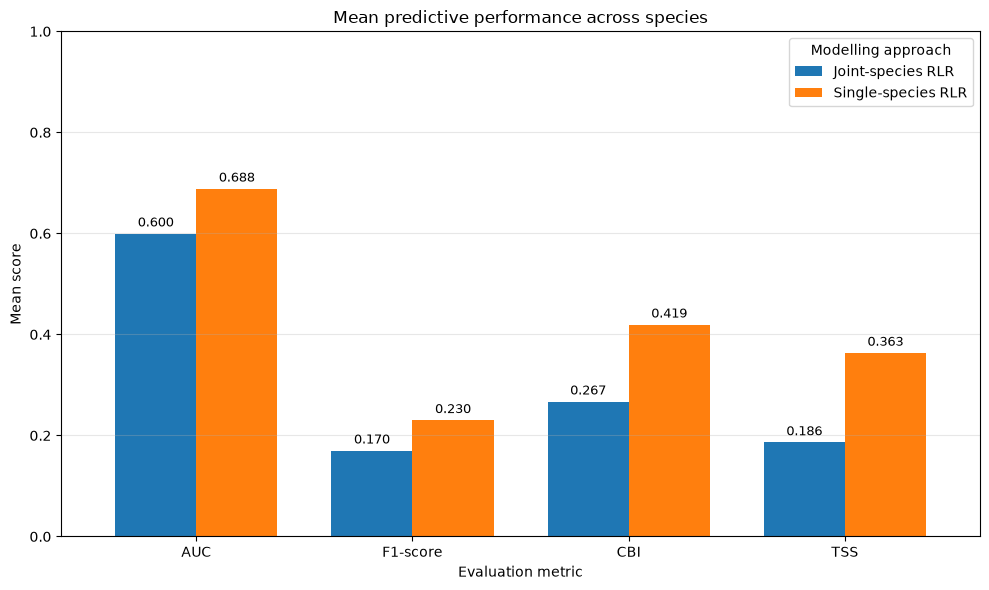

In [29]:
import matplotlib.pyplot as plt

higher_metrics = [
    "auc",
    "f1",
    "continuous_boyce_index",
    "tss",
]

mean_performance_plot = (
    mean_metric_comparison[
        higher_metrics
    ]
    .rename(
        columns={
            "auc": "AUC",
            "f1": "F1-score",
            "continuous_boyce_index": "CBI",
            "tss": "TSS",
        }
    )
    .T
)

ax = mean_performance_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75,
)

ax.set_title(
    "Mean predictive performance across species"
)

ax.set_xlabel("Evaluation metric")
ax.set_ylabel("Mean score")
ax.set_ylim(0, 1)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

ax.legend(
    title="Modelling approach"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9,
    )

plt.tight_layout()
plt.show()

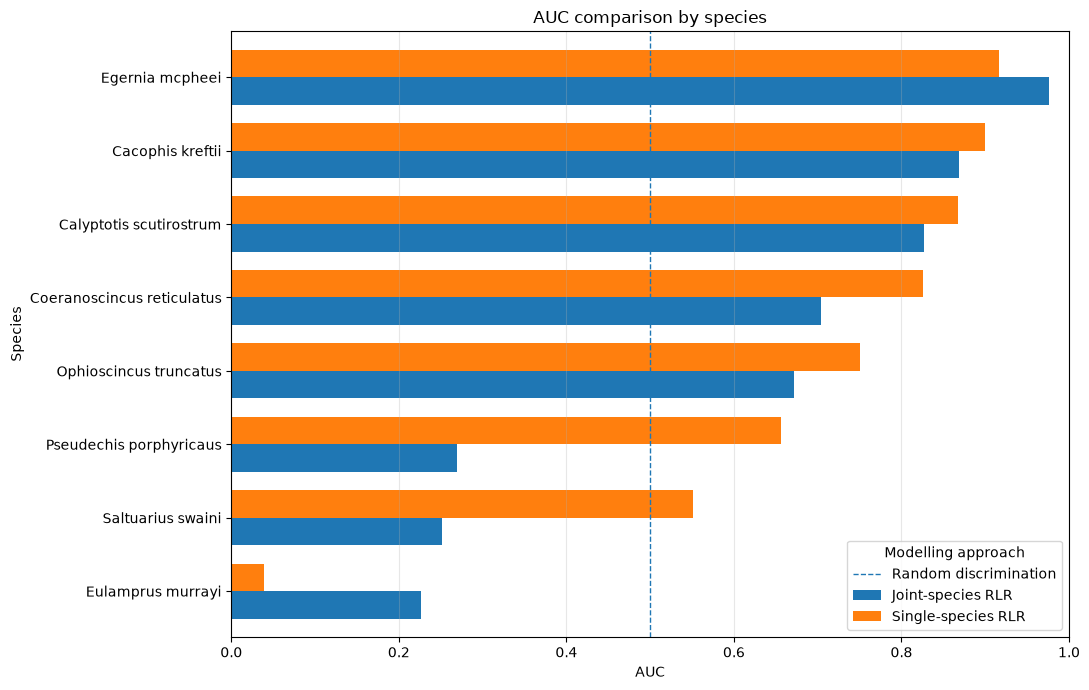

In [30]:
auc_by_species = comparison.pivot(
    index="species",
    columns="model_type",
    values="auc",
)

auc_by_species = auc_by_species.sort_values(
    by="Single-species RLR",
    ascending=True,
)

ax = auc_by_species.plot(
    kind="barh",
    figsize=(11, 7),
    width=0.75,
)

ax.set_title(
    "AUC comparison by species"
)

ax.set_xlabel("AUC")
ax.set_ylabel("Species")
ax.set_xlim(0, 1)

ax.axvline(
    x=0.5,
    linestyle="--",
    linewidth=1,
    label="Random discrimination",
)

ax.grid(
    axis="x",
    alpha=0.3,
)

ax.legend(
    title="Modelling approach",
    loc="lower right",
)

plt.tight_layout()
plt.show()

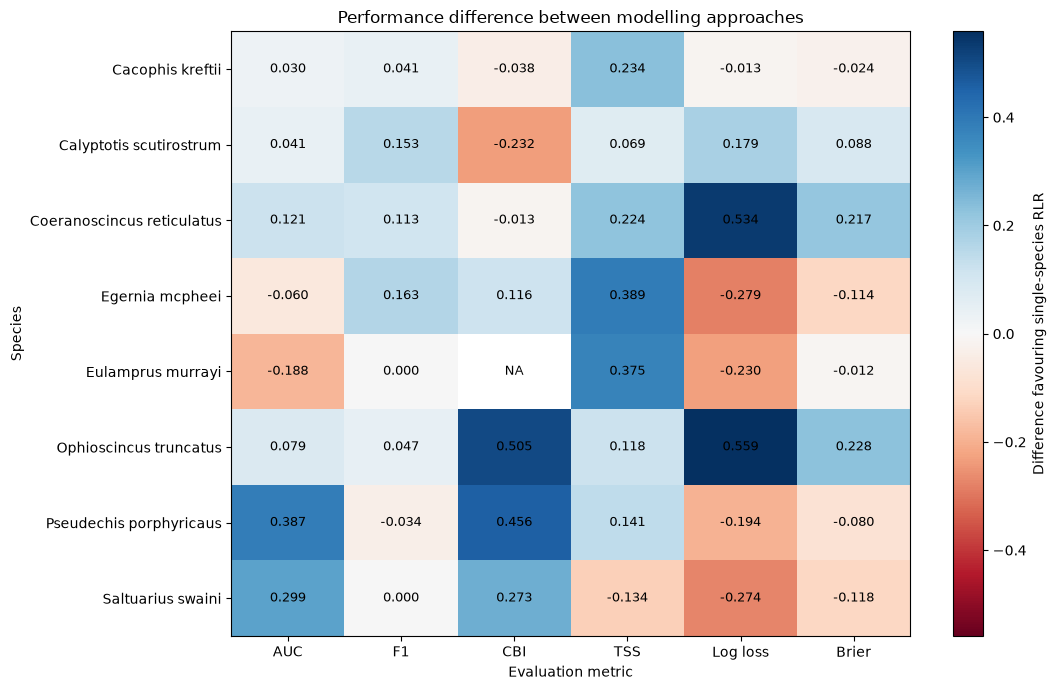

In [31]:
comparison_wide = comparison.pivot(
    index="species",
    columns="model_type",
    values=metric_columns,
)

performance_difference = pd.DataFrame(
    index=comparison_wide.index
)

# Higher is better.
for metric in [
    "auc",
    "f1",
    "continuous_boyce_index",
    "tss",
]:
    performance_difference[metric] = (
        comparison_wide[
            metric
        ]["Single-species RLR"]
        - comparison_wide[
            metric
        ]["Joint-species RLR"]
    )

# Lower is better, so reverse the subtraction.
for metric in [
    "log_loss",
    "brier_score",
]:
    performance_difference[metric] = (
        comparison_wide[
            metric
        ]["Joint-species RLR"]
        - comparison_wide[
            metric
        ]["Single-species RLR"]
    )

performance_difference = (
    performance_difference.rename(
        columns={
            "auc": "AUC",
            "f1": "F1",
            "log_loss": "Log loss",
            "continuous_boyce_index": "CBI",
            "brier_score": "Brier",
            "tss": "TSS",
        }
    )
)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

maximum_difference = np.nanmax(
    np.abs(
        performance_difference.to_numpy()
    )
)

image = ax.imshow(
    performance_difference.to_numpy(),
    aspect="auto",
    cmap="RdBu",
    vmin=-maximum_difference,
    vmax=maximum_difference,
)

ax.set_title(
    "Performance difference between modelling approaches"
)

ax.set_xlabel("Evaluation metric")
ax.set_ylabel("Species")

ax.set_xticks(
    range(
        len(
            performance_difference.columns
        )
    )
)

ax.set_xticklabels(
    performance_difference.columns
)

ax.set_yticks(
    range(
        len(
            performance_difference.index
        )
    )
)

ax.set_yticklabels(
    performance_difference.index
)

for row_index in range(
    performance_difference.shape[0]
):
    for column_index in range(
        performance_difference.shape[1]
    ):
        value = performance_difference.iloc[
            row_index,
            column_index,
        ]

        label = (
            "NA"
            if pd.isna(value)
            else f"{value:.3f}"
        )

        ax.text(
            column_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontsize=9,
        )

colour_bar = fig.colorbar(
    image,
    ax=ax,
)

colour_bar.set_label(
    "Difference favouring single-species RLR"
)

plt.tight_layout()
plt.show()

In [32]:
pooled_single_true = []
pooled_single_probabilities = []

for species_name, datasets in single_species_data.items():

    validation_data = datasets[
        "val"
    ]

    y_true_species = (
        validation_data[
            TARGET_COLUMN
        ]
        .astype(int)
        .to_numpy()
    )

    y_prob_species = (
        single_species_predictions[
            species_name
        ]
    )

    pooled_single_true.extend(
        y_true_species
    )

    pooled_single_probabilities.extend(
        y_prob_species
    )

pooled_single_true = np.asarray(
    pooled_single_true
)

pooled_single_probabilities = np.asarray(
    pooled_single_probabilities
)

print(
    "Pooled single-species observations:",
    len(pooled_single_true),
)

print(
    "Joint-species observations:",
    len(y_joint_val),
)

Pooled single-species observations: 1026
Joint-species observations: 1026


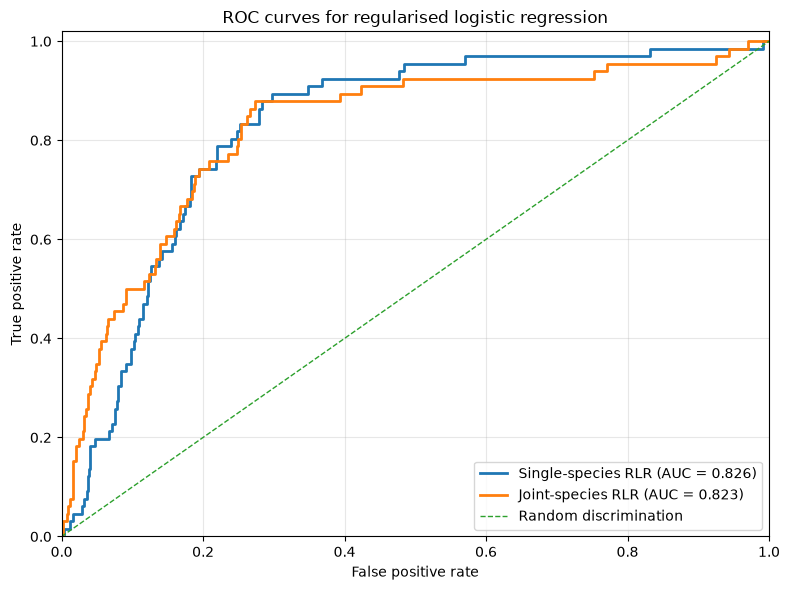

In [33]:
single_fpr, single_tpr, _ = roc_curve(
    pooled_single_true,
    pooled_single_probabilities,
)

joint_fpr, joint_tpr, _ = roc_curve(
    y_joint_val,
    joint_probabilities,
)

single_auc = roc_auc_score(
    pooled_single_true,
    pooled_single_probabilities,
)

joint_auc = roc_auc_score(
    y_joint_val,
    joint_probabilities,
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    single_fpr,
    single_tpr,
    linewidth=2,
    label=(
        "Single-species RLR "
        f"(AUC = {single_auc:.3f})"
    ),
)

plt.plot(
    joint_fpr,
    joint_tpr,
    linewidth=2,
    label=(
        "Joint-species RLR "
        f"(AUC = {joint_auc:.3f})"
    ),
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random discrimination",
)

plt.title(
    "ROC curves for regularised logistic regression"
)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.grid(alpha=0.3)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

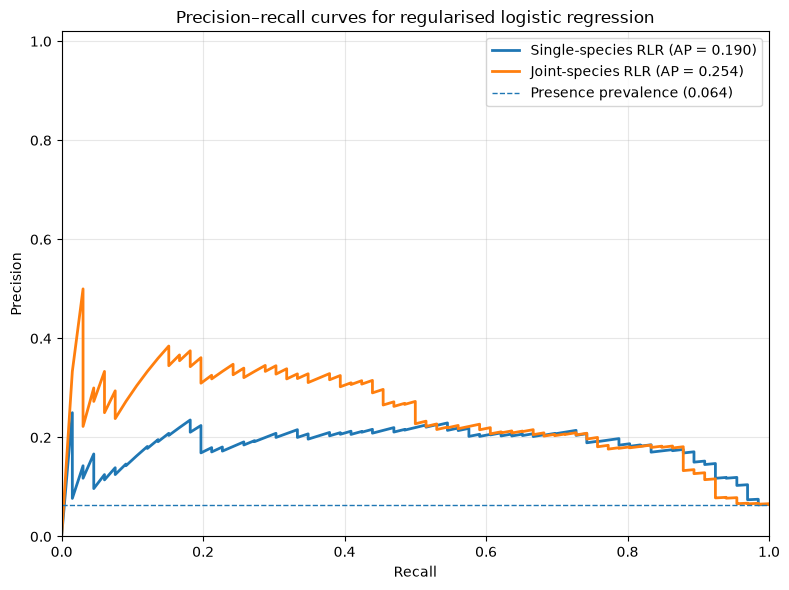

In [34]:
single_precision, single_recall, _ = (
    precision_recall_curve(
        pooled_single_true,
        pooled_single_probabilities,
    )
)

joint_precision, joint_recall, _ = (
    precision_recall_curve(
        y_joint_val,
        joint_probabilities,
    )
)

single_average_precision = (
    average_precision_score(
        pooled_single_true,
        pooled_single_probabilities,
    )
)

joint_average_precision = (
    average_precision_score(
        y_joint_val,
        joint_probabilities,
    )
)

baseline_prevalence = (
    y_joint_val.mean()
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    single_recall,
    single_precision,
    linewidth=2,
    label=(
        "Single-species RLR "
        f"(AP = {single_average_precision:.3f})"
    ),
)

plt.plot(
    joint_recall,
    joint_precision,
    linewidth=2,
    label=(
        "Joint-species RLR "
        f"(AP = {joint_average_precision:.3f})"
    ),
)

plt.axhline(
    baseline_prevalence,
    linestyle="--",
    linewidth=1,
    label=(
        "Presence prevalence "
        f"({baseline_prevalence:.3f})"
    ),
)

plt.title(
    "Precision–recall curves for regularised logistic regression"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.grid(alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()